# AKI Calculation - Gather Covariates and Recreate Model (Notebook 4 of 4) 

## Description

These notebooks are our first attempt to identify the subjects with AKI in our cohort, based on the KDIGO SCr criteria.

The code to calculate AKI within the VPS-PN cohort can be found here: https://github.com/Lab-for-Integrated-Decision-Support/vps-peds-mods. The relevant code and folders are:

The general process of this notebook is as follows:

- Gather covariates - recall that for the original model, this includes "cardiac arrest pre-admission" which we will have to get from diagnoses codes, and "post-operative" which we likely cannot include.
- Calculate AKI risk based on the Sanchez-Pinto 2016 coefficients on the covariates
  - Generate an ROC curve based on this score and report the AUROC
  - Calculate the thresholds at 50% and 90% and report results

### Initialize and Load Functions

First we set the folder path, and define the function `load_data_file` to load the specific PDC data file from this folder.

In [1]:
import pandas as pd
import numpy
import os, sys, importlib 

import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

try:
    import pyspark
    import pyspark.pandas as ps
except:
    %pip install pyspark
    import pyspark
    import pyspark.pandas as ps

try:
    import plotly.express as px
except:
    %pip install plotly
    import plotly.express as px

import azure_BlobStorageConnection
import load_utils

Set environment variables using script.

In [2]:
from set_env_vars import set_all_env_vars

set_all_env_vars()

Add global debug_ variables to determine when to print out counts, show data tables, and plot graphs. This speeds processing in the PySpark environment, but may not matter if we're working solely with pandas data frames.

In [3]:
debug_count = False
debug_show = False
debug_plot = True

Add variable `save_figs` to indicate whether produced figures should be saved.

In [4]:
save_figs = True

if not os.path.isdir('visualizations'):
    os.mkdir('visualizations')

Load necessary data files.

In [5]:
import azureml.fsspec

uri = 'azureml://subscriptions/b06a3f28-16e7-4bcd-ab95-f192daca58db/resourcegroups/pdc-rg-westus-research/workspaces/pdc-mlw-westus-research1/datastores/pdc_ci_westus_research_readwrite_iam_link/paths/meds-wg/'

labs_lim = pd.read_csv(
    uri + 'labs.csv', 
    usecols=["pdc_hid", "pdc_pid", "resulttime", "pdc_name", "source_units", "source_value"]
)

Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration


In [6]:
base_cohort = pd.read_csv(os.environ['AKI_DATA_PDC'] + 'base_cohort_v2.csv')

final_aki_cohort = pd.read_csv(os.environ['AKI_DATA_PDC'] + 'final_aki_cohort.csv')

### Gather Covariates

Now that we have the output defined, we gather the covariates necessary to run the prediction model. The labs we need are:

- Post-operative recovery
- Pre-admission cardiac arrest
- BUN (mg/dL) as [BUN]
- pH as [PH_ART, PH_CAP, PH_VEN]
- Platelet count (K/uL) as [PLTS]
- Total bilirubin (mg/dL) as [BILIRUBIN_TOT]
- Age (yrs)

#### Labs

First we write a function which will pull labs based on a list of lab aliases:

In [7]:
for col in labs_lim.columns:
    print(col)

pdc_pid
pdc_hid
pdc_name
resulttime
source_value
source_units


In [8]:
def get_labs(lab_list, labs_lim, base_cohort, debug_count, debug_show):
    """
    Gather labs of a certain PDC type
    """
    
    # Filter the labs to the types of interest
    labs_res = labs_lim[labs_lim['pdc_name'].isin(lab_list)]
    
    # Convert necessary columns to numbers
    get_numeric = lambda val: float(val) if (val and str(val).replace('.', '').isdigit()) else numpy.nan
    labs_res['val_numeric'] = [get_numeric(val) for val in labs_res['source_value']]
    # labs_res['val_numeric'] = labs_res['source_value'].astype(float)
    labs_res['n_res_time'] = labs_res['resulttime'].astype('long')
    labs_res.drop_duplicates(inplace=True)
    
    if debug_count: print('Number of rows of all values for lab types passed in: %d' % len(labs_res))
    
    # Join to base cohort
    labs_res_join = base_cohort.merge(
        labs_res,
        on=['pdc_hid', 'pdc_pid'],
        how='left'
    ) \
    .drop_duplicates()
    if debug_count: print('Number of rows in left join: %d' % len(labs_res_join))
    
    # Filter to include only those with the time in between the ICU admission and +12 hours
    labs_res_join['result_after_admit'] = [1 if gte else 0 for gte in (labs_res_join['n_res_time'] >= labs_res_join['n_icuadmit'])]
    labs_res_join['12hrs_after_admit'] = [n_admit + 12*60*60 for n_admit in labs_res_join['n_icuadmit']]
    labs_res_join['result_lte_12hrs_after_admit'] = [1 if lte else 0 for lte in (labs_res_join['n_res_time'] <= labs_res_join['12hrs_after_admit'])]
    labs_res_join['keep_lab'] = labs_res_join['result_after_admit'] * labs_res_join['result_lte_12hrs_after_admit']
    labs_res_join_filter = labs_res_join[labs_res_join['keep_lab'] == 1]
    # labs_res_join_filter = labs_res_join[
    #     (labs_res_join['n_res_time'] >= labs_res_join['n_icuadmit']) and (labs_res_join['n_res_time'] <= [n_admit + 12*60 for n_admit in labs_res_join['n_icuadmit']])
    # ]
    if debug_count: print('Number of filtered rows in ICU-only dataset: %d' % len(labs_res_join_filter))
    
    if debug_show: display(labs_res_join_filter.head())
    
    return labs_res_join_filter

Now we apply that function to pull labs:

In [9]:
# pH Values
ph_res = get_labs(
    ['PH_ART', 'PH_VEN', 'PH_CAP'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered pH values.')

# Blood Urea Nitrogen Values
bun_res = get_labs(
    ['BUN'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered blood urea nitrogen values.')

# Platelet Count Values
plt_res = get_labs(
    ['PLTS'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered platelet count values.')

# Bilirubin Values
bili_res = get_labs(
    ['BILIRUBIN_TOT'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered bilirubin values.')

Gathered pH values.
Gathered blood urea nitrogen values.
Gathered platelet count values.
Gathered bilirubin values.


To ensure that we don't have unit discrepencies, we write a function to summarize the values (using https://stackoverflow.com/questions/33575587/pandas-dataframe-how-to-apply-describe-to-each-group-and-add-to-new-columns as reference for group_summarize() function):

In [10]:
def group_summarize(source_df, group_var, sum_var):
    """
    Summarize a dataframe by a grouping variable.
    """
    
    df = source_df.groupby(group_var).describe()#.unstack(1)
    
    display(df)
    
def report_src_units(source_df):
    """
    Generate a table of counts by site and source units
    """
    
    df = source_df.rename(columns={'pdc_pid': 'count'})[[
        'site_id',
        'source_units',
        'count'
    ]] \
    .groupby(['site_id', 'source_units']) \
    .count() \
    .reset_index() \
    .sort_values(['site_id', 'source_units'])
    
    display(df)

And we apply those functions on the above-extracted data frames:

In [11]:
if debug_count:
    print('pH')
    group_summarize(ph_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')
    print('\nbun')
    group_summarize(bun_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')
    print('\nplt')
    group_summarize(plt_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')
    print('\nbili')
    group_summarize(bili_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')

In [12]:
if debug_count:
    print('pH')
    report_src_units(ph_res)
    print('bun')
    report_src_units(bun_res)
    print('plt')
    report_src_units(plt_res)
    print('bili')
    report_src_units(bili_res)

#### Cardiac Arrest Diagnoses

Now we have to pull the cardiac arrest diagnoses. We begin by loading the diagnoses file (`conditionsprocs`). We then scan the conditions for codes which match cardiac arrest codes.

In [13]:
# diags_df = load_utils.load_data_file(file = 'conditionsprocs', blob_datastore = d_s, path = '8-site-pandas/', debug = debug_count)

import azureml.fsspec

uri = 'azureml://subscriptions/b06a3f28-16e7-4bcd-ab95-f192daca58db/resourcegroups/pdc-rg-westus-research/workspaces/pdc-mlw-westus-research1/datastores/pdc_ci_westus_research_readwrite_iam_link/paths/meds-wg/'

diags_df = pd.read_csv(
    uri + 'conditionsprocs.csv',
    on_bad_lines='skip'
)

The cell below is the one where we search for cardiac arrest and summarize those codes below:

In [14]:
diags_df['lower_text'] = [text.lower() for text in diags_df['codetext']]

diags_df = diags_df[diags_df['lower_text'].str.contains('cardiac arrest')]

Now we identify encounters which had one of these codes present:

In [15]:
code_list = ['I46.9', 'I46.8', 'I462', 'I469', 'I468', '427.5', 'I46.2']

ca_diags = diags_df[diags_df['code'].isin(code_list)][[
    'pdc_hid', 
    'site_id'
]].drop_duplicates()

ca_diags['cardiac_arrest'] = [1 for i in range(len(ca_diags))]

if debug_count: print('Number of rows in the cardiac arrest diagnoses dataframe: %d' % len(ca_diags))

if debug_show: ca_diags.head()

## Generate model

Now that we have all of the covariates we can identify, we bring them together in a dataframe to be used for the creation of the AKI prediction model.

<AxesSubplot: xlabel='site_id', ylabel='age_admit_yrs'>

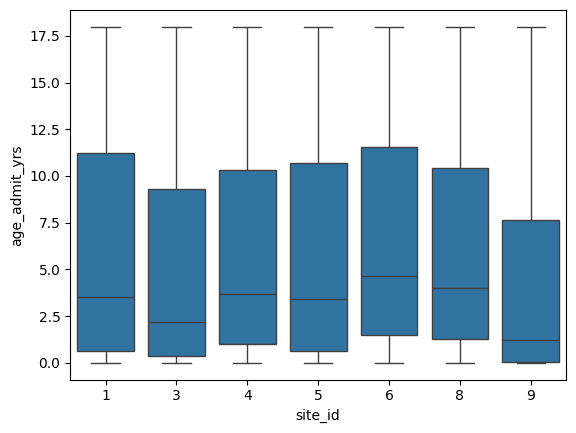

In [16]:
sns.boxplot(
    final_aki_cohort,
    y='age_admit_yrs',
    x='site_id'
)

In [17]:
cohort_w_covar = final_aki_cohort.copy()

cohort_w_covar['coeff_age'] = cohort_w_covar['age_admit_yrs'] * 0.02

"""
Prepare dataframes for each lab type and join to cohort
"""

# pH
# Ranges:
# x < 7.21
# x >= 7.21

min_pH = ph_res[[
    'pdc_hid', 
    'pdc_eid', 
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.min() \
.reset_index() \
.rename(columns = {'val_numeric': 'min_ph'})

cohort_w_covar = cohort_w_covar.merge(
    min_pH,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['min_ph_is_na'] = cohort_w_covar['min_ph'].isna()
cohort_w_covar['min_ph'].fillna(7.4, inplace=True)
cohort_w_covar['coeff_ph'] = numpy.where(
    cohort_w_covar['min_ph'] < 7.21,
    1.04, # if true
    0     # else
)

# Blood Urea Nitrogen
# Ranges:
# x < 15
# 15 <= x < 25
# x >= 25

max_bun = bun_res[[
    'pdc_hid',
    'pdc_eid',
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.max() \
.reset_index() \
.rename(columns = {'val_numeric': 'max_bun'})

cohort_w_covar = cohort_w_covar.merge(
    max_bun,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['max_bun_is_na'] = cohort_w_covar['max_bun'].isna()
cohort_w_covar['max_bun'].fillna(0, inplace=True)
cohort_w_covar['coeff_bun'] = numpy.where(
    cohort_w_covar['max_bun'] < 15,
    0, # bun < 15
    numpy.where(
        cohort_w_covar['max_bun'] < 25,
        0.73, # 15 <= bun < 25
        2.02 # 25 <= bun
    )
)

# Platelet Count
# Ranges:
# x < 50
# 50 <= x < 95
# 95 <= x < 175
# x >= 175

min_plt = plt_res[[
    'pdc_hid',
    'pdc_eid',
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.min() \
.reset_index() \
.rename(columns = {'val_numeric': 'min_plt'})

cohort_w_covar = cohort_w_covar.merge(
    min_plt,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['min_plt_is_na'] = cohort_w_covar['min_plt'].isna()
cohort_w_covar['min_plt'].fillna(200, inplace=True)
cohort_w_covar['coeff_plt'] = numpy.where(
    cohort_w_covar['min_plt'] < 50,
    1.43,
    numpy.where(
        cohort_w_covar['min_plt'] < 95,
        0.95,
        numpy.where(
            cohort_w_covar['min_plt'] < 175,
            0.59,
            0
        )
    )
)

# Bilirubin
# Ranges:
# x < 0.6
# 0.6 <= x < 17.9
# x >= 17.9

max_bili = bili_res[[
    'pdc_hid',
    'pdc_eid',
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.max() \
.reset_index() \
.rename(columns = {'val_numeric': 'max_bili'})

cohort_w_covar = cohort_w_covar.merge(
    max_bili,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['max_bili_is_na'] = cohort_w_covar['max_bili'].isna()
cohort_w_covar['max_bili'].fillna(0, inplace=True)
cohort_w_covar['coeff_bili'] = numpy.where(
    cohort_w_covar['max_bili'] < 0.6,
    0,
    numpy.where(
        cohort_w_covar['max_bili'] < 18,
        0.34,
        2.41
    )
)

# Cardiac arrest


cohort_w_covar = cohort_w_covar.merge(
    ca_diags,
    on=['pdc_hid', 'site_id'],
    how='left'
)
cohort_w_covar['coeff_ca'] = numpy.where(
    cohort_w_covar['cardiac_arrest'].isnull(),
    0,
    1.55
)

# Raw aki_score
coeff_cols = [col for col in cohort_w_covar.columns if 'coeff' in col]
cohort_w_covar['aki_score_raw'] = [coef_sum - 4.12 for coef_sum in cohort_w_covar[coeff_cols].sum(axis=1)]
cohort_w_covar['aki_score'] = [numpy.exp(aki_score_raw) / (1 + numpy.exp(aki_score_raw)) for aki_score_raw in cohort_w_covar['aki_score_raw']]

cohort_w_covar['aki_score_raw_no_constant'] = cohort_w_covar[coeff_cols].sum(axis=1)
cohort_w_covar['aki_score_no_constant'] = [numpy.exp(aki_score_raw) / (1 + numpy.exp(aki_score_raw)) for aki_score_raw in cohort_w_covar['aki_score_raw_no_constant']]

### Save risk scores and actual AKI status to CSV for later analysis

In [18]:
cohort_w_covar[['pdc_pid', 'pdc_hid', 'pdc_eid', 'cardiac_arrest']].to_csv('cardiac_arrest_status_and_IDs.csv', index=False)

In [19]:
print('\n'.join(cohort_w_covar.columns))

pdc_hid
pdc_eid
site_id
icumortality
pdc_pid
n_icuadmit
age_admit_yrs
max_aki_admit
max_aki_stay
new_aki
coeff_age
min_ph
min_ph_is_na
coeff_ph
max_bun
max_bun_is_na
coeff_bun
min_plt
min_plt_is_na
coeff_plt
max_bili
max_bili_is_na
coeff_bili
cardiac_arrest
coeff_ca
aki_score_raw
aki_score
aki_score_raw_no_constant
aki_score_no_constant


In [21]:
cohort_w_covar['aki_72hrs_any'] = numpy.where(
    cohort_w_covar['new_aki']=='AKI',
    1,
    0
)

cohort_w_covar.drop('aki_72hrs_any', axis=1, inplace=True)

In [22]:
cohort_w_covar['ca_is_na'] = numpy.where(
    cohort_w_covar['cardiac_arrest'].isnull(),
    1,
    0
)

cohort_w_covar['coeff_na_count'] = cohort_w_covar[[col for col in cohort_w_covar.columns if 'is_na' in col]].sum(axis=1)

cohort_w_covar['coeff_na_count'].value_counts()

5.0    52405
2.0    22748
3.0    21651
4.0    20113
1.0    13023
0.0      784
Name: coeff_na_count, dtype: int64

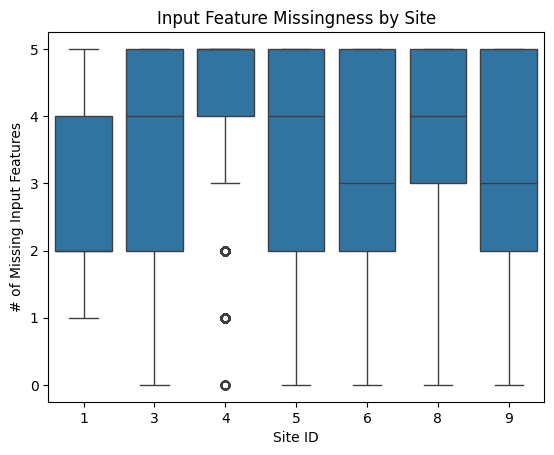

In [23]:
fig, ax = plt.subplots()

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='coeff_na_count',
    ax=ax
) \
.set(
    xlabel='Site ID',
    ylabel='# of Missing Input Features',
    title='Input Feature Missingness by Site'
)

if save_figs:
    fig.savefig('visualizations/input_feature_missing_count_by_patient_and_site_boxplot.png', dpi=fig.dpi)

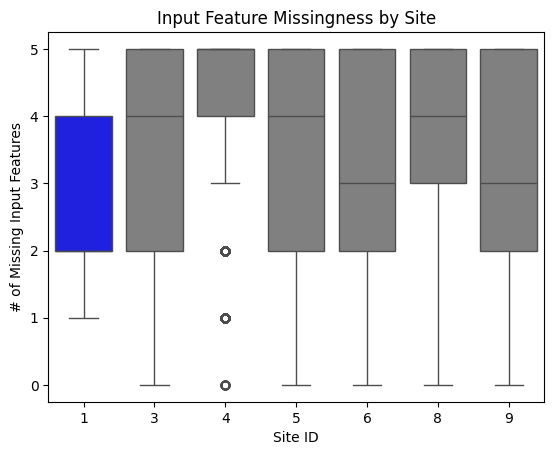

In [24]:
fig, ax = plt.subplots()

cohort_w_covar['is_site_1'] = [1 if site_id == 1 else 0 for site_id in cohort_w_covar['site_id']]

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='coeff_na_count',
    hue='is_site_1',
    palette=['grey', 'blue'],
    ax=ax,
    dodge=False
) \
.set(
    xlabel='Site ID',
    ylabel='# of Missing Input Features',
    title='Input Feature Missingness by Site'
)

plt.legend([],[], frameon=False)

# if save_figs:
#     fig.savefig('visualizations/input_feature_missing_count_by_patient_and_site_boxplot.png', dpi=fig.dpi)

In [25]:
for col in cohort_w_covar.columns:
    if '_is_na' in col:
        print(col + ' mean')
        print('%.3f\n' %cohort_w_covar[col].mean())

min_ph_is_na mean
0.641

max_bun_is_na mean
0.546

min_plt_is_na mean
0.578

max_bili_is_na mean
0.819

ca_is_na mean
0.980



<AxesSubplot: xlabel='site_id', ylabel='aki_score'>

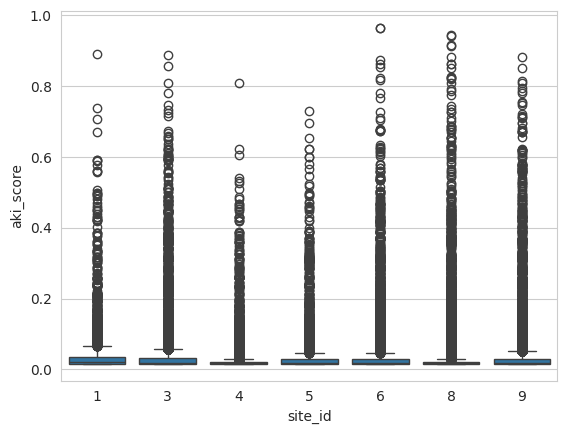

In [26]:
sns.set_style('whitegrid')

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='aki_score'
)

<AxesSubplot: xlabel='site_id', ylabel='aki_score_raw'>

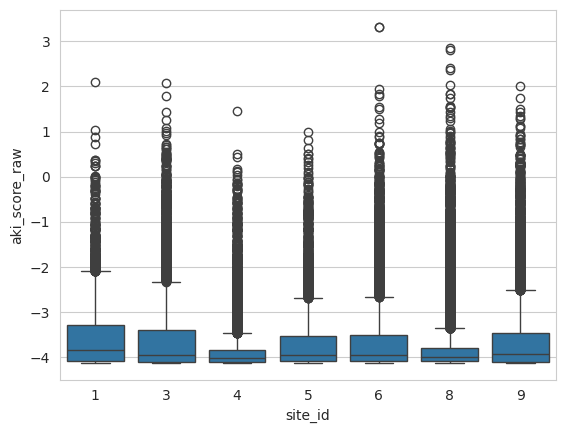

In [27]:
sns.set_style('whitegrid')

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='aki_score_raw'
)

<AxesSubplot: ylabel='aki_score'>

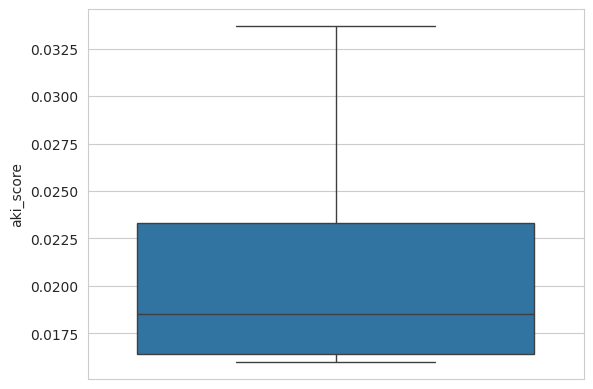

In [28]:
sns.set_style('whitegrid')

sns.boxplot(
    cohort_w_covar,
    # x='site_id',
    y='aki_score',
    showfliers=False
)

In [29]:
cohort_w_covar[[
    'site_id',
    'min_ph_is_na',
    'max_bun_is_na',
    'min_plt_is_na',
    'max_bili_is_na'
]] \
.groupby('site_id') \
.mean() \
.reset_index() \
.rename(
    columns = {
        'min_ph_is_na': 'min_ph',
        'max_bun_is_na': 'max_bun',
        'min_plt_is_na': 'min_plt',
        'max_bili_is_na': 'max_bili'
    }
) \
.melt(
    id_vars='site_id',
    value_vars=[
        'min_ph',
        'max_bun',
        'min_plt',
        'max_bili'
    ]
) \
.sort_values('site_id') \
.groupby(['variable']) \
.mean() \
.reset_index()

,variable,site_id,value
0,max_bili,5.142857,0.807610
1,max_bun,5.142857,0.525799
2,min_ph,5.142857,0.614584
3,min_plt,5.142857,0.559371


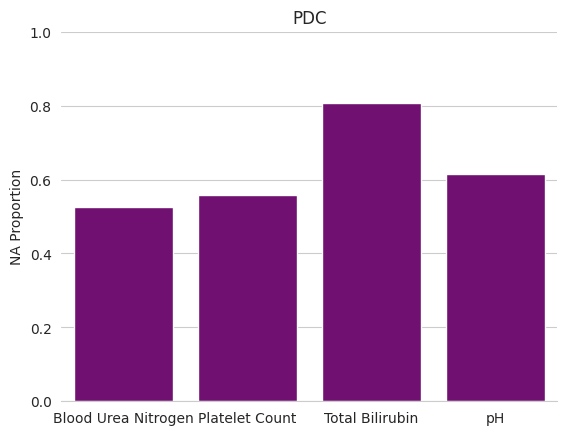

In [30]:
sns.set_style('whitegrid')

fig, ax = plt.subplots()



sns.barplot(
    cohort_w_covar[[
        'site_id',
        'min_ph_is_na',
        'max_bun_is_na',
        'min_plt_is_na',
        'max_bili_is_na'
    ]] \
    .groupby('site_id') \
    .mean() \
    .reset_index() \
    .rename(
        columns = {
            'min_ph_is_na': 'pH',
            'max_bun_is_na': 'Blood Urea Nitrogen',
            'min_plt_is_na': 'Platelet Count',
            'max_bili_is_na': 'Total Bilirubin'
        }
    ) \
    .melt(
        id_vars='site_id',
        value_vars=[
            'Total Bilirubin',
            'pH',
            'Platelet Count',
            'Blood Urea Nitrogen'
        ]
    ) \
    .sort_values('site_id') \
    .groupby(['variable']) \
    .mean() \
    .reset_index() \
    .sort_values('variable'),
    x='variable',
    y='value',
    color='purple'
).set(
    xlabel=None,
    ylabel='NA Proportion',
    title='PDC',
    ylim=[0,1]
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# plt.legend(title='site_id', bbox_to_anchor=(1.05, 1))

# if save_figs:
#     fig.savefig('visualizations/lab_value_missingness_by_site_grouped_by_type.png', dpi=fig.dpi)

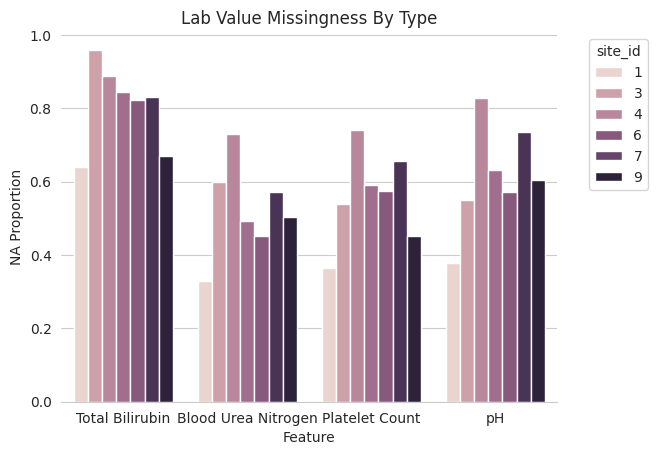

In [31]:
sns.set_style('whitegrid')

fig, ax = plt.subplots()

sns.barplot(
    cohort_w_covar[[
        'site_id',
        'min_ph_is_na',
        'max_bun_is_na',
        'min_plt_is_na',
        'max_bili_is_na'
    ]] \
    .groupby('site_id') \
    .mean() \
    .reset_index() \
    .rename(
        columns = {
            'min_ph_is_na': 'pH',
            'max_bun_is_na': 'Blood Urea Nitrogen',
            'min_plt_is_na': 'Platelet Count',
            'max_bili_is_na': 'Total Bilirubin'
        }
    ) \
    .melt(
        id_vars='site_id',
        value_vars=[
            'Total Bilirubin',
            'pH',
            'Platelet Count',
            'Blood Urea Nitrogen'
            # 'min_ph',
            # 'max_bun',
            # 'min_plt',
            # 'max_bili'
        ]
    ) \
    .sort_values('site_id'),
    x='variable',
    y='value',
    hue='site_id'
).set(
    xlabel='Feature',
    ylabel='NA Proportion',
    title='Lab Value Missingness By Type'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.legend(title='site_id', bbox_to_anchor=(1.05, 1))

if save_figs:
    fig.savefig('visualizations/lab_value_missingness_by_site_grouped_by_type.png', dpi=fig.dpi)

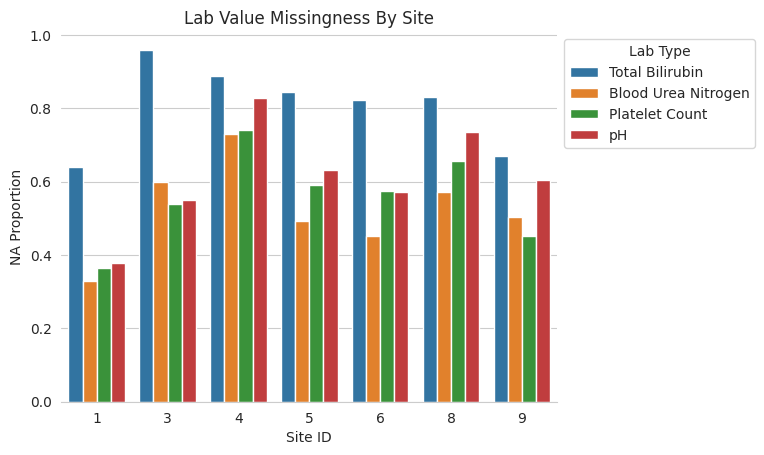

In [32]:
sns.set_style('whitegrid')

fig, ax = plt.subplots()

sns.barplot(
    cohort_w_covar[[
        'site_id',
        'min_ph_is_na',
        'max_bun_is_na',
        'min_plt_is_na',
        'max_bili_is_na'
    ]] \
    .groupby('site_id') \
    .mean() \
    .reset_index() \
    .rename(
        columns = {
            'min_ph_is_na': 'pH',
            'max_bun_is_na': 'Blood Urea Nitrogen',
            'min_plt_is_na': 'Platelet Count',
            'max_bili_is_na': 'Total Bilirubin'
            # 'min_ph_is_na': 'min_ph',
            # 'max_bun_is_na': 'max_bun',
            # 'min_plt_is_na': 'min_plt',
            # 'max_bili_is_na': 'max_bili'
        }
    ) \
    .melt(
        id_vars='site_id',
        value_vars=[
            'Total Bilirubin',
            'pH',
            'Platelet Count',
            'Blood Urea Nitrogen'
            # 'min_ph',
            # 'max_bun',
            # 'min_plt',
            # 'max_bili'
        ]
    ) \
    .sort_values('site_id'),
    x='site_id',
    y='value',
    hue='variable'
).set(
    xlabel='Site ID',
    ylabel='NA Proportion',
    title='Lab Value Missingness By Site'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.legend(title='Lab Type', bbox_to_anchor=(1.0, 1))

if save_figs:
    fig.savefig('visualizations/lab_value_missingness_by_type_grouped_by_site.png', dpi=fig.dpi)

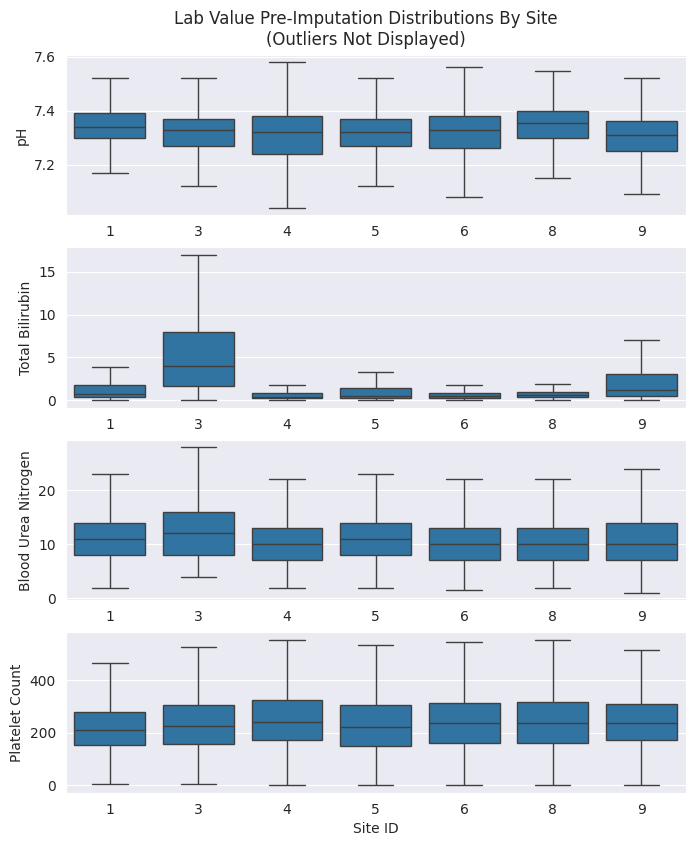

In [33]:
sns.set_style('darkgrid')

fig, axes = plt.subplots(
    4, 1, 
    figsize=(8, 9)#,
    # sharex=True
)

lab_types = [
    'min_ph',
    'max_bili',
    'max_bun',
    'min_plt'
]

lab_name_dict = {
    'min_ph': 'pH',
    'max_bili': 'Total Bilirubin',
    'max_bun': 'Blood Urea Nitrogen',
    'min_plt': 'Platelet Count'
}

for i in range(len(lab_types)):
    temp_lab_type = lab_types[i]
    temp_ax = axes[i]
    temp_df = cohort_w_covar[~cohort_w_covar[temp_lab_type+'_is_na']].sort_values('site_id')
    
    sns.boxplot(
        temp_df,
        x = 'site_id',
        y = temp_lab_type,
        ax = temp_ax,
        showfliers=False
    ) \
    .set(
        # title = temp_lab_type,
        xlabel=None,
        ylabel=lab_name_dict[temp_lab_type]
    )
    # temp_ax.set_xticks(numpy.arange(len(cohort_w_covar['site_id'].sort_values().unique())))
    # temp_ax.set_xticklabels(cohort_w_covar['site_id'].sort_values().unique())
    
    if i == len(lab_types) - 1:
        temp_ax.set(xlabel='Site ID')

plt.subplots_adjust(top=0.93)
fig.suptitle('Lab Value Pre-Imputation Distributions By Site' + '\n' + '(Outliers Not Displayed)')
# fig.tight_layout()

if save_figs:
    fig.savefig('visualizations/lab_value_dist_boxplots_by_type_and_site_no_outliers.png', dpi=fig.dpi)

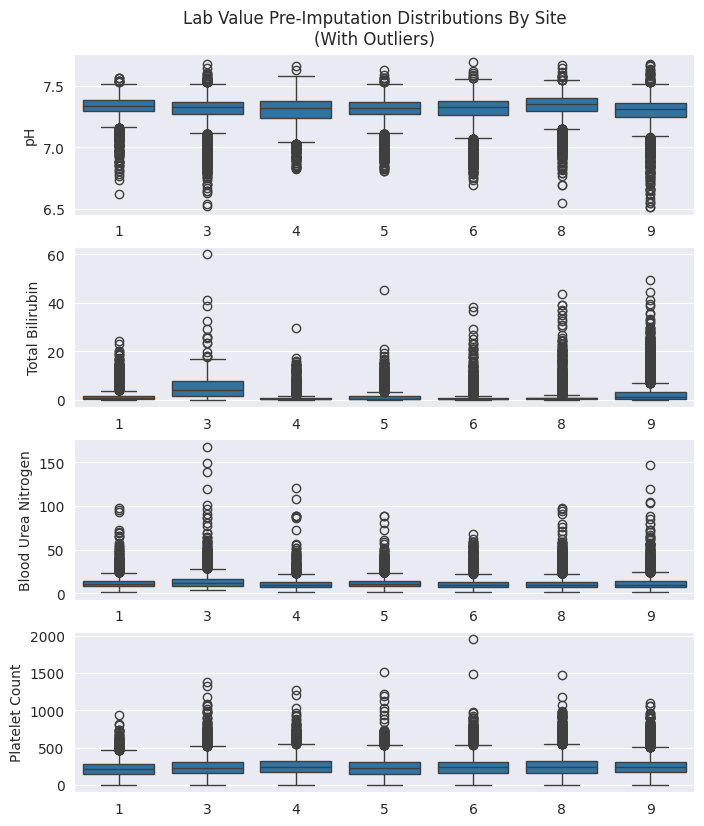

In [34]:
sns.set_style('darkgrid')

fig, axes = plt.subplots(
    4, 1, 
    figsize=(8, 9),
    # sharex=True
)

lab_types = [
    'min_ph',
    'max_bili',
    'max_bun',
    'min_plt'
]

lab_name_dict = {
    'min_ph': 'pH',
    'max_bili': 'Total Bilirubin',
    'max_bun': 'Blood Urea Nitrogen',
    'min_plt': 'Platelet Count'
}

for i in range(len(lab_types)):
    temp_lab_type = lab_types[i]
    temp_ax = axes[i]
    temp_df = cohort_w_covar[~cohort_w_covar[temp_lab_type+'_is_na']]
    
    sns.boxplot(
        temp_df,
        x = 'site_id',
        y = temp_lab_type,
        ax = temp_ax
    ) \
    .set(
        # title = temp_lab_type,
        xlabel=None,
        ylabel=lab_name_dict[temp_lab_type]
    )

plt.subplots_adjust(top=0.93)
fig.suptitle('Lab Value Pre-Imputation Distributions By Site' + '\n' + '(With Outliers)')
# fig.tight_layout()

if save_figs:
    fig.savefig('visualizations/lab_value_dist_boxplots_by_type_and_site.png', dpi=fig.dpi)

In [35]:
coeff_cols

['coeff_age', 'coeff_ph', 'coeff_bun', 'coeff_plt', 'coeff_bili', 'coeff_ca']

In [36]:
cohort_w_covar.head().T

,0,1,2,3,4
pdc_hid,104171001,103775001,106863001,103586001,102639001
pdc_eid,104033001,104035001,104038001,104039001,104041001
site_id,1,1,1,1,1
icumortality,0.0,0.0,0.0,0.0,0.0
pdc_pid,102005001,102644001,105275001,105277001,101684001
n_icuadmit,1800,180,17580,2100,1086240
age_admit_yrs,12.837782,17.965777,3.753593,3.321013,2.781656
max_aki_admit,0.0,0.0,0.0,0.0,0.0
max_aki_stay,0.0,0.0,0.0,0.0,0.0
new_aki,No AKI,No AKI,No AKI,No AKI,No AKI


In [37]:
if debug_show:
    group_summarize(cohort_w_covar, 'site_id', 'aki_score')
    
if debug_count:
    print('Number of rows in cohort_w_covar: %d' % len(cohort_w_covar))

## Analyze Performance

We'll begin analysis of model performance by looking at all encounters where we know whether or not the patient had AKI at 72 hours after admission.

### All Encounters With Known True AKI Status

#### AUC

We use the `roc_auc_score` function from scikit-learn to calculate the AUROC of the determined risk scores:

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

We also use the `average_precision_score` function from scikit-learn to calculate the area under the precision-recall curve, which is equivalent to average precision score:

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html

In [38]:
print('Count of available rows: %d' % len(cohort_w_covar[cohort_w_covar['new_aki'].isin(['No AKI','AKI'])]))

Count of available rows: 130724


Calculate the Area Under the ROC and PR Curve!

In [39]:
from sklearn.metrics import roc_auc_score, average_precision_score

cohort_w_covar['aki_72hrs_any'] = numpy.where(
    cohort_w_covar['new_aki']=='AKI',
    1,
    0
)

true_target_df = cohort_w_covar[cohort_w_covar['new_aki'].isin(['No AKI','AKI'])]

y_true = true_target_df['aki_72hrs_any'].to_numpy()
y_score = true_target_df['aki_score'].to_numpy()

auroc = roc_auc_score(y_true, y_score)

print('AUROC = %.4f' % auroc)

auprc = average_precision_score(y_true, y_score)

print('AUPRC = %.4f' % auprc)

AUROC = 0.6014
AUPRC = 0.0632


#### ROC Plot

We now use the `roc_curve` function from scikit-learn to generate the points on the ROC curve and plot it with matplotlib.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve

In [40]:
def get_true_false_pos_neg(y_true, y_pred):
    true_pred = (y_true == y_pred).astype(int)
    false_pred = (y_true != y_pred).astype(int)
    
    tp = sum(((y_pred == 1).astype(int) * true_pred).astype(int))
    tn = sum(((y_pred == 0).astype(int) * true_pred).astype(int))
    fp = sum(((y_pred == 1).astype(int) * false_pred).astype(int))
    fn = sum(((y_pred == 0).astype(int) * false_pred).astype(int))
    
    return tp, tn, fp, fn

def get_tpr_fpr(y_true, y_score, thresh):
    y_pred = (y_score > thresh).astype(int)
    tp, tn, fp, fn = get_true_false_pos_neg(y_true, y_pred)
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return (tpr, fpr)

def get_fine_tuned_roc_df(y_true, y_score, threshold_step=0.0001):
    thresholds = numpy.arange(0, 1 + threshold_step, threshold_step)
    tpr_fpr = numpy.array([get_tpr_fpr(y_true, y_score, thresh) for thresh in thresholds])
    
    roc_df = pd.DataFrame(
        {
            'tpr': tpr_fpr[:,0],
            'fpr': tpr_fpr[:,1],
            'thresholds': thresholds
        }
    )
    
    return roc_df

In [41]:
true_target_df[
    (true_target_df['aki_score'] < 0.0160) & \
    (true_target_df['aki_score'] >= 0.0159) &\
    (true_target_df['aki_72hrs_any']==1)
]['aki_score'].value_counts()

0.015985    753
0.015986     24
0.015987      8
0.015989      3
0.015987      2
0.015995      2
0.015994      2
0.015990      2
0.015993      1
0.015993      1
0.015991      1
0.015996      1
Name: aki_score, dtype: int64

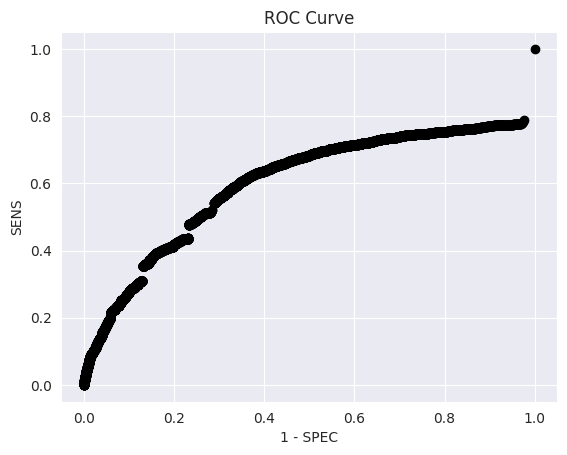

In [42]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.xlabel('1 - SPEC')
plt.ylabel('SENS')
plt.title('ROC Curve')

plt.scatter(
    fpr,
    tpr,
    # c=thresholds
    color='black'
)

Export ROC curve info to CSV.

In [43]:
ROC_df = pd.DataFrame({
    'fpr': fpr,
    'tpr': tpr,
    'threshold': thresholds
})

ROC_df.to_csv(os.environ['AKI_DATA_PDC'] + 'ROC_points_single_center_model.csv', index=False)

In [44]:
ROC_df.sort_values('threshold', ascending=False)

,fpr,tpr,threshold
0,0.000000,0.000000,inf
1,0.000008,0.000000,0.965124
2,0.000031,0.000000,0.943214
3,0.000031,0.000281,0.917024
4,0.000071,0.000281,0.882765
...,...,...,...
15373,0.971282,0.778746,0.015988
15374,0.972485,0.779308,0.015987
15375,0.973845,0.781557,0.015987
15376,0.977156,0.788305,0.015986


#### Precision-Recall Curve

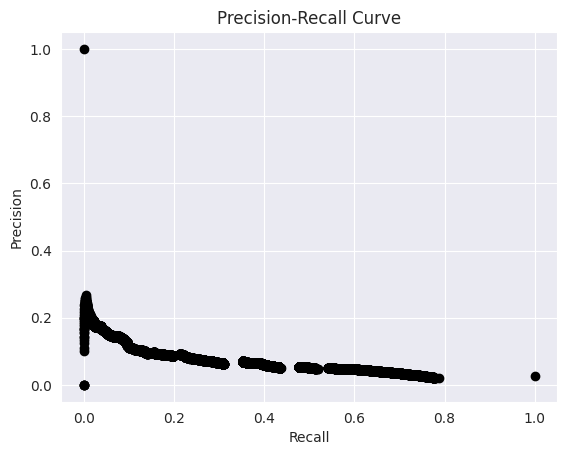

In [45]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_score)

fig, ax = plt.subplots()

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')

ax.scatter(
    recall,
    precision,
    # c=thresholds
    color='black'
)



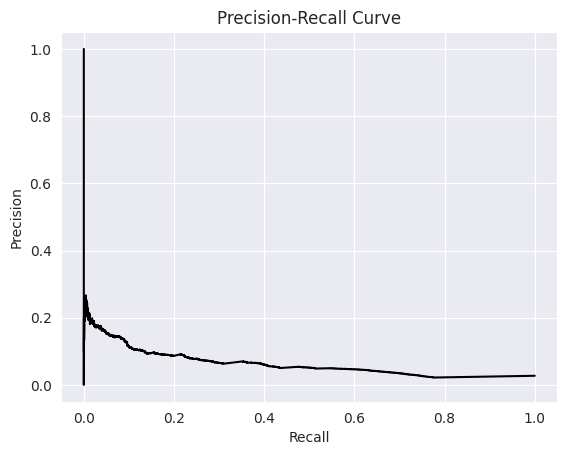

In [46]:
fig, ax = plt.subplots()

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')

ax.plot(
    recall,
    precision,
    # c=thresholds
    color='black'
)
ax.set_xlim([-0.05,1.05])
ax.set_ylim([-0.05,1.05])

if save_figs:
    fig.savefig('visualizations/PRC - validated_original_model.png', dpi=fig.dpi)

#### Cutpoint analysis

Now we have to identify the 50th and 90th percentile cut points and identify the SENS, SPEC, and PPV for these cut points.



In [47]:
def get_positive_proportion_at_thresh(y_score, thresh):
    y_pred = (y_score > thresh).astype(int)
    pos_count = y_pred.sum()
    total_count = len(y_pred)
    pos_prop = pos_count / total_count
    return pos_prop

def get_cutpoint_threshold(y_true, y_score, cutpoint=0.5, threshold_step=0.001):
    thresholds = numpy.arange(0, 1, 0.001)
    positive_proportions = [get_positive_proportion_at_thresh(y_score, thresh) for thresh in thresholds]
    
    pos_prop_by_threshold = pd.DataFrame(
        {
            'threshold': thresholds,
            'pos_prop': positive_proportions
        }
    )
    
    target_proportion = 1 - cutpoint
    pos_prop_by_threshold['proportion_diff_from_target'] = [abs(prop - target_proportion) for prop in pos_prop_by_threshold['pos_prop']]
    min_diff_from_target = pos_prop_by_threshold['proportion_diff_from_target'].min()
    
    target_threshold = pos_prop_by_threshold[pos_prop_by_threshold['proportion_diff_from_target']==min_diff_from_target].iloc[0]['threshold']
    
    return target_threshold

In [48]:
def get_true_false_pos_neg(y_true, y_pred):
    true_pred = (y_true == y_pred).astype(int)
    false_pred = (y_true != y_pred).astype(int)
    
    tp = sum(((y_pred == 1).astype(int) * true_pred).astype(int))
    tn = sum(((y_pred == 0).astype(int) * true_pred).astype(int))
    fp = sum(((y_pred == 1).astype(int) * false_pred).astype(int))
    fn = sum(((y_pred == 0).astype(int) * false_pred).astype(int))
    
    return tp, tn, fp, fn

def get_sensitivity(tp, fn):
    return tp / (tp + fn)

def get_specificity(tn, fp):
    return tn / (tn + fp)

def get_ppv(tp, fp):
    return tp / (tp + fp)

In [49]:
cutpoint_50_threshold = get_cutpoint_threshold(y_true, y_score, cutpoint=0.5, threshold_step=0.001)
cutpoint_90_threshold = get_cutpoint_threshold(y_true, y_score, cutpoint=0.9, threshold_step=0.001)

y_pred_cutpoint_50 = (y_score > cutpoint_50_threshold).astype(int)
y_pred_cutpoint_90 = (y_score > cutpoint_90_threshold).astype(int)

print('Proportion of patients classified as positive at cut point 50: %.3f' % (sum(y_pred_cutpoint_50) / len(y_pred_cutpoint_50)))
print('Proportion of patients classified as positive at cut point 90: %.3f' % (sum(y_pred_cutpoint_90) / len(y_pred_cutpoint_90)))

Proportion of patients classified as positive at cut point 50: 0.474
Proportion of patients classified as positive at cut point 90: 0.101


In [50]:
print('Cutpoint 90:')
tp90, tn90, fp90, fn90 = get_true_false_pos_neg(y_true, y_pred_cutpoint_90)
print('SENS = %.4f' % get_sensitivity(tp90, fn90))
print('SPEC = %.4f' % get_specificity(tn90, fp90))
print('PPV = %.4f\n' % get_ppv(tp90, fp90))

print('Cutpoint 50:')
tp50, tn50, fp50, fn50 = get_true_false_pos_neg(y_true, y_pred_cutpoint_50)
print('SENS = %.4f' % get_sensitivity(tp50, fn50))
print('SPEC = %.4f' % get_specificity(tn50, fp50))
print('PPV = %.4f' % get_ppv(tp50, fp50))

Cutpoint 90:
SENS = 0.2699
SPEC = 0.9037
PPV = 0.0727

Cutpoint 50:
SENS = 0.6699
SPEC = 0.5320
PPV = 0.0385


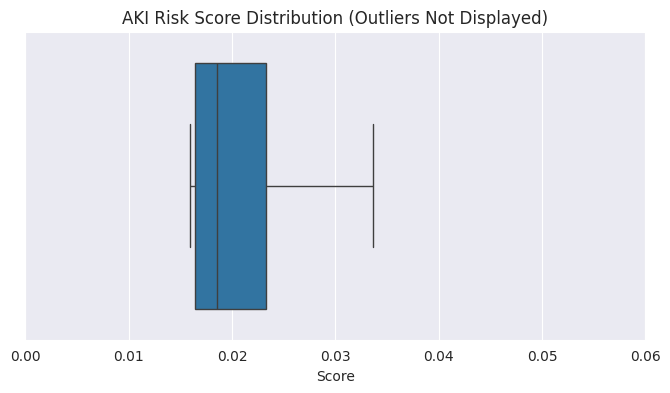

In [51]:
fig, ax = plt.subplots(figsize=(8,4))

sns.boxplot(
    cohort_w_covar,
    x='aki_score',
    showfliers=False
) \
.set(
    xlabel='Score',
    title='AKI Risk Score Distribution (Outliers Not Displayed)',
    xlim=[0,0.06]
)

if save_figs:
    fig.savefig('visualizations/aki_risk_score_boxplot_no_outliers - original_model.png', dpi=fig.dpi)

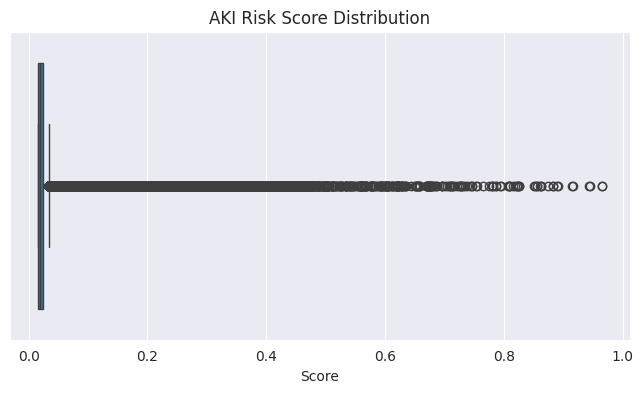

In [52]:
fig, ax = plt.subplots(figsize=(8,4))

sns.boxplot(
    cohort_w_covar,
    x='aki_score'
) \
.set(
    xlabel='Score',
    title='AKI Risk Score Distribution'
)

if save_figs:
    fig.savefig('visualizations/aki_risk_score_boxplot - original_model.png', dpi=fig.dpi)